# Importando bibliotecas

In [1]:
from typing import List, Dict, Tuple, Literal
import itertools
import math

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import Levenshtein


try:
    from caas_jupyter_tools import display_dataframe_to_user
except ModuleNotFoundError:
    from IPython.display import display
    def display_dataframe_to_user(title, df):
        print(title)
        display(df)

# Pre-set dos dados

## Sagas analisadas

In [2]:
# ---- Harry Potter ----
hp_all = [
    "HP1",
    "HP2",
    "HP3",
    "HP4",
    "HP5",
    "HP6",
    "HP7",
    "HP8",
]

# ---- Star Wars ----
sw_all = [
    "SW1",
    "SW2",
    "SW3",
    "SW4",
    "SW5",
    "SW6",
    "SW7",
    "SW8",
    "SW9",
    "SWX",
]

## Rankings da Ale (os certos)

In [3]:

hp_Ale = [
    "HP2",
    "HP4",
    "HP1",
    "HP3",
    "HP5",
    "HP7",
    "HP8",
    "HP6",   
]

sw_Ale = [
    "SW5",
    "SW6",
    "SW7",
    "SW4",
    "SW1",
    "SW8",
    "SWX",  
    "SW3",
    "SW9",   
    "SW2",
]


## Rankings do Leo (beeem questionáveis)

In [4]:
hp_Leo = [
    "HP6",
    "HP4",
    "HP5",
    "HP3",
    "HP1",
    "HP7",
    "HP8", # premissa: como você não rankeou o pt2, deliberadamente pus ele depois do pt1 (obv)
    "HP2",
]


sw_Leo = [
    "SW5",
    "SW6",
    "SW3",
    "SWX",
    "SW4",
    "SW1",
    "SW2",
    "SW7",
    "SW8",
    "SW9",
]


In [5]:
combined_Ale = hp_Ale + sw_Ale
combined_Leo = hp_Leo + sw_Leo

# Funções de apoio

In [6]:
def ranks_map(seq: List[str]) -> Dict[str, int]:
    """Mapeia cada item para sua posição (1-indexed)."""
    return {item: i+1 for i, item in enumerate(seq)}

In [7]:
def levenshtein_distance(seq1: List[str], seq2: List[str]) -> int:
    s1 = "\n".join(seq1)
    s2 = "\n".join(seq2)
    return Levenshtein.distance(s1, s2)

def wmape_on_ranks(reference_seq: List[str], compared_seq: List[str]) -> float:

    ref_ranks = ranks_map(reference_seq)
    cmp_ranks = ranks_map(compared_seq)

    common_items = [it for it in ref_ranks.keys() if it in cmp_ranks]
    if not common_items:
        return float("nan")

    abs_errors = sum(abs(ref_ranks[it] - cmp_ranks[it]) for it in common_items)
    denom = sum(ref_ranks[it] for it in common_items)
    return abs_errors / denom if denom != 0 else float("nan")

In [8]:
def compare_block(name: str, seqA: List[str], seqB: List[str]) -> Dict[str, float]:
    lev = levenshtein_distance(seqA, seqB)
    wm = wmape_on_ranks(seqA, seqB)
    return {"Bloco": name, "Levenshtein": lev, "WMAPE_ranks(A→B)": wm}

def build_pair_dataframe(label: str, seqA: List[str], seqB: List[str]) -> pd.DataFrame:
    ref = ranks_map(seqA)
    cmp_ = ranks_map(seqB)
    rows = []
    for it in sorted(set(ref.keys()) | set(cmp_.keys())):
        a_pos = ref.get(it, np.nan)
        b_pos = cmp_.get(it, np.nan)
        abs_diff = np.nan
        contrib = np.nan
        if it in ref and it in cmp_:
            abs_diff = abs(a_pos - b_pos)
            denom = sum(ref.values())  # constante para o bloco, mas repetimos aqui para transparência
            contrib = abs_diff / denom if denom != 0 else np.nan
        rows.append({"Bloco": label, "Filme": it, "rank_Ale": a_pos, "rank_Leo": b_pos, "abs_diff": abs_diff, "contrib_WMAPE": contrib})
    return pd.DataFrame(rows)

# Exploração de algoritmos 

## Levenshtein & WMape

In [10]:
# Detalhes por franquia
hp_metrics = compare_block("Harry Potter", hp_Ale, hp_Leo)
sw_metrics = compare_block("Star Wars", sw_Ale, sw_Leo)
combined_metrics = compare_block("Combinado HP+SW", combined_Ale, combined_Leo)

metrics_df = pd.DataFrame([hp_metrics, sw_metrics, combined_metrics])
metrics_df["WMAPE_ranks(Ale→Leo)_pct"] = metrics_df["WMAPE_ranks(A→B)"] * 100
metrics_df.rename(columns={"WMAPE_ranks(A→B)": "WMAPE_ranks(Ale→Leo)"}, inplace=True)
metrics_df.drop(columns=["WMAPE_ranks(Ale→Leo)"], inplace=True)

# Detalhes por item
hp_details = build_pair_dataframe("Harry Potter", hp_Ale, hp_Leo)
sw_details = build_pair_dataframe("Star Wars", sw_Ale, sw_Leo)


combined_details = build_pair_dataframe("Combinado HP+SW", combined_Ale, combined_Leo)


In [11]:
display_dataframe_to_user("Detalhamento por filme - Harry Potter", hp_details)
display_dataframe_to_user("Detalhamento por filme - Star Wars", sw_details)

Detalhamento por filme - Harry Potter


,Bloco,Filme,rank_Ale,rank_Leo,abs_diff,contrib_WMAPE
0,Harry Potter,HP1,3,5,2,0.055556
1,Harry Potter,HP2,1,8,7,0.194444
2,Harry Potter,HP3,4,4,0,0.000000
3,Harry Potter,HP4,2,2,0,0.000000
4,Harry Potter,HP5,5,3,2,0.055556
5,Harry Potter,HP6,8,1,7,0.194444
6,Harry Potter,HP7,6,6,0,0.000000
7,Harry Potter,HP8,7,7,0,0.000000


Detalhamento por filme - Star Wars


,Bloco,Filme,rank_Ale,rank_Leo,abs_diff,contrib_WMAPE
0,Star Wars,SW1,5,6,1,0.018182
1,Star Wars,SW2,10,7,3,0.054545
2,Star Wars,SW3,8,3,5,0.090909
3,Star Wars,SW4,4,5,1,0.018182
4,Star Wars,SW5,1,1,0,0.000000
5,Star Wars,SW6,2,2,0,0.000000
6,Star Wars,SW7,3,8,5,0.090909
7,Star Wars,SW8,6,9,3,0.054545
8,Star Wars,SW9,9,10,1,0.018182
9,Star Wars,SWX,7,4,3,0.054545


OBS: 
- Apesar de não servir para isso, o WMape funcionou do jeito que a gente queria! Olha a penalização pelo HP2 e HP6 ksksksksksk;
- Achei legal ver como "desencontrar" um rankeamento em Star Wars é menos sofrido do que em Harry Potter porque SW tem muito mais filme (bem, talvez isso fosse meio óbvio pelo jeito como o WMmape calcula erro mas não tinha percebido ontem de noite);

In [12]:
display_dataframe_to_user("Detalhamento por item - Combinado", combined_details)
display_dataframe_to_user("Métricas por bloco (Levenshtein & WMAPE em ranks)", metrics_df)

Detalhamento por item - Combinado


,Bloco,Filme,rank_Ale,rank_Leo,abs_diff,contrib_WMAPE
0,Combinado HP+SW,HP1,3,5,2,0.011696
1,Combinado HP+SW,HP2,1,8,7,0.040936
2,Combinado HP+SW,HP3,4,4,0,0.000000
3,Combinado HP+SW,HP4,2,2,0,0.000000
4,Combinado HP+SW,HP5,5,3,2,0.011696
5,Combinado HP+SW,HP6,8,1,7,0.040936
6,Combinado HP+SW,HP7,6,6,0,0.000000
7,Combinado HP+SW,HP8,7,7,0,0.000000
8,Combinado HP+SW,SW1,13,14,1,0.005848
9,Combinado HP+SW,SW2,18,15,3,0.017544


Métricas por bloco (Levenshtein & WMAPE em ranks)


,Bloco,Levenshtein,WMAPE_ranks(Ale→Leo)_pct
0,Harry Potter,4,50.000000
1,Star Wars,8,40.000000
2,Combinado HP+SW,12,23.391813


OBS:
- Aqui provamos sua "intuição com base em economia política", e que intuição hein!
- Por Levenshtein nosso rank de SW é mais distante do que HP (óbviamente, maior número de filmes, maior quantidade de mudanças), mas convenhamos... Olhando o WMape temos ao contrário hehe!
- Insana intuição, economista :)
- Tomei a liberdade de fazer uma análise conjunta de sagas! No fim das contas não temos gostos taaaaao diferentes assim quando olhando pelo WMape. Aparentemente temos um match de ~76,61%!

Ideias & Futuras discussões:
- É injusta a comparação por Levenshtein já que SW tem mais filmes que HP, por isso pensei em normalizar a distância para ter uma comparação que leva em conta a quantidade de oportunidades de troca!
- Depois de refletir, a análise combinada de HP+SW só faz sentido se nós dois concordarmos todos os filmes de HP são melhores que qualquer filme de SW - o que para mim é um absurdo tenebroso! Precisamos discutir premissas da análise conjunta de gostos.

## Levenshtein Normalizado

- Para esse approach, vou dividir a distância pelo tamanho da maior lista de filmes. 

In [13]:
metrics_df = pd.DataFrame([hp_metrics, sw_metrics, combined_metrics])
metrics_df["WMAPE_ranks(Ale→Leo)_pct"] = metrics_df["WMAPE_ranks(A→B)"] * 100
metrics_df.rename(columns={"WMAPE_ranks(A→B)": "WMAPE_ranks(Ale→Leo)"}, inplace=True)

def normalizador(bloco: str) -> int:
    max_len = 9
    if bloco == "Harry Potter":
        return max_len
    elif bloco == "Star Wars":
        return max_len
    else:  # Combinado HP+SW
        return 17

metrics_df["Levenshtein_norm"] = metrics_df.apply(
    lambda row: row["Levenshtein"] / normalizador(row["Bloco"]),
    axis=1
)

metrics_df.drop(columns=["WMAPE_ranks(Ale→Leo)"], inplace=True)
metrics_df.drop(columns=["WMAPE_ranks(Ale→Leo)_pct"], inplace=True)
display_dataframe_to_user("Métricas consolidadas (com Levenshtein normalizado)", metrics_df)

Métricas consolidadas (com Levenshtein normalizado)


,Bloco,Levenshtein,Levenshtein_norm
0,Harry Potter,4,0.444444
1,Star Wars,8,0.888889
2,Combinado HP+SW,12,0.705882


OBS:
- Uou... refutada. Ok, desisto de você Levenshtein, ontem a noite parecia bem mais genial!

## Gráficos legais

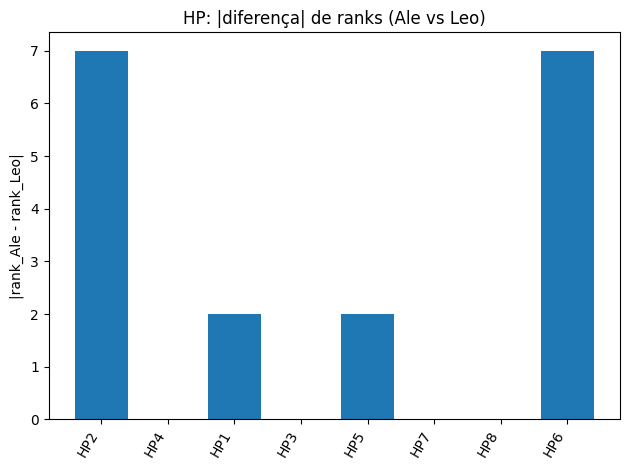

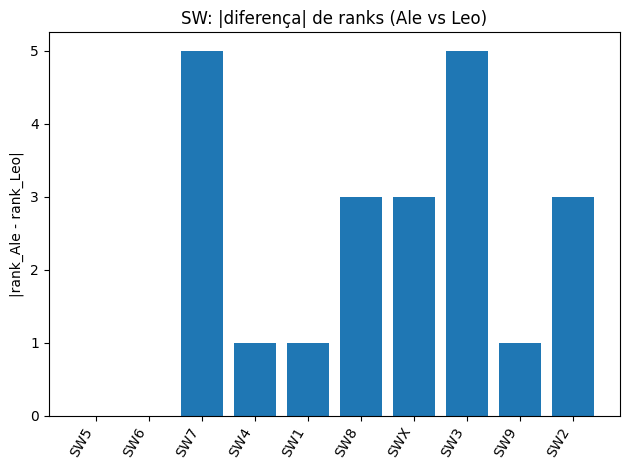

In [14]:
hp_ref = ranks_map(hp_Ale)
hp_cmp = ranks_map(hp_Leo)
hp_items_common = [it for it in hp_ref if it in hp_cmp]
hp_abs_diffs = [abs(hp_ref[it] - hp_cmp[it]) for it in hp_items_common]

plt.figure()
plt.bar(hp_items_common, hp_abs_diffs)
plt.title("HP: |diferença| de ranks (Ale vs Leo)")
plt.xticks(rotation=60, ha='right')
plt.ylabel("|rank_Ale - rank_Leo|")
plt.tight_layout()
plt.show()


sw_ref = ranks_map(sw_Ale)
sw_cmp = ranks_map(sw_Leo)
sw_items_common = [it for it in sw_ref if it in sw_cmp]
sw_abs_diffs = [abs(sw_ref[it] - sw_cmp[it]) for it in sw_items_common]

plt.figure()
plt.bar(sw_items_common, sw_abs_diffs)
plt.title("SW: |diferença| de ranks (Ale vs Leo)")
plt.xticks(rotation=60, ha='right')
plt.ylabel("|rank_Ale - rank_Leo|")
plt.tight_layout()
plt.show()


## Próximas análises
- Comecei a trocar uma ideia com o GPT, mas ai tive que trabalhar de verdade...
- Achei algumas opções interessantes e novas de algoritimos que não conhecia! Logo mais vem ai na continuação da comparação de rankings!